# Laboratorium 8 - Pierwiastki
Jakub Fabia

## Biblioteki

In [1]:
using Polynomials, Plots, Roots, DataFrames, ForwardDiff, DataFrames, Colors

# Zadanie A - Poszukiwanie pierwiastków

In [2]:
tests = [
    ("sin(x) - x/2", x -> sin(x) - x/2),
    ("cos(x) - x", x -> cos(x) - x),
    ("(x+3)*(x-1)^2", x -> (x+3)*(x-1)^2),
    ("20x/(100x² + 1)", x -> 20.0*x/(100.0*x*x + 1.0)),
    ("x*exp(-x)", x -> x*exp(-x)),
    ("2x - exp(-x)", x -> 2*x - exp(-x)),
    ("exp(x) - 10x", x -> exp(x) - 10*x)
]


df = DataFrame(TestFunction=String[], Method=Function[], Iterations=Int64[], FunctionCalls=Int64[], result=Float64[])

tracker = Roots.Tracks()
falsepos(f) = find_zero(f, (0, 1), FalsePosition(), tracks = tracker) 
D(f) = x -> ForwardDiff.derivative(f, float(x))
newtonMethod(f) = find_zero((f, D(f)), 0, Roots.Newton(), tracks = tracker)
steffenson(f) = find_zero(f, 0, Order8(), tracks = tracker)

for (name, test) in tests
    res1 = falsepos(test)
    if abs(test(res1)) > 1e-8
        println("FalsePosition error on test: ", name, " result: ", test(res1))
    end
    push!(df, (name, falsepos, tracker.steps, tracker.fncalls, last(tracker)))
    empty!(tracker)

    res2 = newtonMethod(test)
    if abs(test(res2)) > 1e-8
        println("Newton error on test: ", name, " result: ", test(res2))
    end
    push!(df, (name, newtonMethod, tracker.steps, tracker.fncalls, last(tracker)))
    empty!(tracker)

    res3 = steffenson(test)
    if abs(test(res3)) > 1e-8
        println("Steffenson error on test: ", name, " result: ", test(res3))
    end
    push!(df, (name, steffenson, tracker.steps, tracker.fncalls, last(tracker)))
    empty!(tracker)
end

print(df)


21×5 DataFrame
 Row │ TestFunction     Method        Iterations  FunctionCalls  result
     │ String           Function      Int64       Int64          Float64
─────┼───────────────────────────────────────────────────────────────────────
   1 │ sin(x) - x/2     falsepos              40             42  9.09495e-13
   2 │ sin(x) - x/2     newtonMethod           1              2  0.0
   3 │ sin(x) - x/2     steffenson             0              2  0.0
   4 │ cos(x) - x       falsepos               6              8  0.739085
   5 │ cos(x) - x       newtonMethod           5             10  0.739085
   6 │ cos(x) - x       steffenson             5             10  0.739085
   7 │ (x+3)*(x-1)^2    falsepos               0              2  1.0
   8 │ (x+3)*(x-1)^2    newtonMethod          26             52  1.0
   9 │ (x+3)*(x-1)^2    steffenson            15             38  1.0
  10 │ 20x/(100x² + 1)  falsepos              40             42  9.09495e-13
  11 │ 20x/(100x² + 1)  newtonMethod     

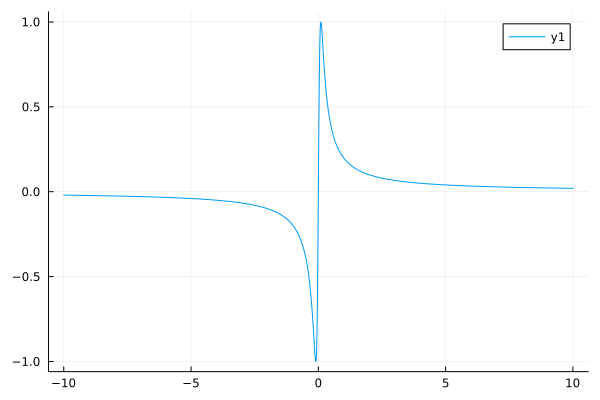

In [3]:
f(x) = 20.0*x/(100.0*x*x+1.0)
xs = -10:10
plot(f, extrema(xs)...)

In [4]:
empty!(tracker)
falsepos(f)
tracker

Results of univariate zero finding:

* Converged to: 9.094947017729282e-13
* Algorithm: FalsePosition{:anderson_bjork}()
* iterations: 40
* function evaluations ≈ 42

Trace:
x₁ = 0,	 fx₁ = 0
x₂ = 1,	 fx₂ = 0.19801980198019803
x₃ = 0.5,	 fx₃ = 0.38461538461538464
x₄ = 0.25,	 fx₄ = 0.68965517241379315
x₅ = 0.125,	 fx₅ = 0.97560975609756095
x₆ = 0.0625,	 fx₆ = 0.898876404494382
x₇ = 0.03125,	 fx₇ = 0.56939501779359436
x₈ = 0.015625,	 fx₈ = 0.30505243088655865
x₉ = 0.0078125,	 fx₉ = 0.1553021111380733
x₁₀ = 0.00390625,	 fx₁₀ = 0.078005972332256687
x₁₁ = 0.001953125,	 fx₁₁ = 0.03904760452098046
x₁₂ = 0.0009765625,	 fx₁₂ = 0.019529387532469515
x₁₃ = 0.00048828125,	 fx₁₃ = 0.0097653921749073294
x₁₄ = 0.000244140625,	 fx₁₄ = 0.0048827833963430147
x₁₅ = 0.0001220703125,	 fx₁₅ = 0.0024414026120266139
x₁₆ = 6.103515625e-05,	 fx₁₆ = 0.0012207026702528185
x₁₇ = 3.0517578125e-05,	 fx₁₇ = 0.00061035150565658645
x₁₈ = 1.52587890625e-05,	 fx₁₈ = 0.00030517577414457281
x₁₉ = 7.62939453125e-06,	 fx₁₉ = 0

In [5]:
empty!(tracker)
newtonMethod(f)
tracker

Results of univariate zero finding:

* Converged to: 0.0
* Algorithm: Roots.Newton()
* iterations: 1
* function evaluations ≈ 2
* stopped as f(x_n) = 0

Trace:
x₁ = 0,	 fx₁ = 0
x₂ = 0,	 fx₂ = 0



In [6]:
empty!(tracker)
steffenson(f)
tracker

Results of univariate zero finding:

* Converged to: 0.0
* Algorithm: Order8()
* iterations: 0
* function evaluations ≈ 2
* stopped as f(x_n) = 0

Trace:
x₁ = 6.0554544523933395e-06,	 fx₁ = 0.00012110908860377758
x₂ = 0,	 fx₂ = 0



Metoda regula falsi - nie działa przez nieciągłość i rozbieżność funkcji. 

In [7]:
try
    f(x) = x/(x-1) - 1
    xs = -1:2
    empty!(tracker)
    x = find_zero(f, (-1,1), FalsePosition())
catch e
    println(e)
end

Roots.ConvergenceFailed("Algorithm failed to converge")


Metoda siecznych - nie działa przez nieciągłość i rozbieżność funkcji. 

In [8]:
try
    f(x) = x/(x-1) - 1
    xs = -1:2
    empty!(tracker)
    x = find_zero(f, (-1,1), Order8())
catch e
    println(e)
end

Roots.ConvergenceFailed("Algorithm failed to converge")


Metoda Newtona - nie działa przez to, że pochodna w x = 0 nie istnieje 

In [9]:
try
    f(x) = x^(1/3)
    D(f) = x -> ForwardDiff.derivative(f, float(x))
    empty!(tracker)
    find_zero((f, D(f)), -1, Roots.Newton(), tracks = tracker)
catch e
    println(e)
end

DomainError(-1.0, "Exponentiation yielding a complex result requires a complex argument.\nReplace x^y with (x+0im)^y, Complex(x)^y, or similar.")


# Zadanie B - Wstęga Newtona

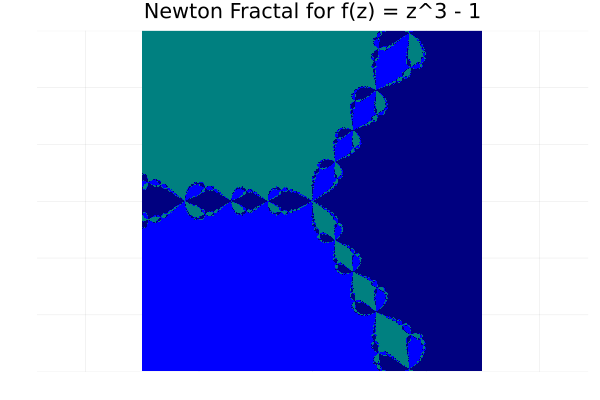

In [10]:
f(z) = z^3 - 1
f′(z) = 3z^2

known_roots = [1.0 + 0im, -0.5 + sqrt(3)/2im, -0.5 - sqrt(3)/2im]

root_colors = [RGB(0, 0, 0.5), RGB(0, 0.5, 0.5), RGB(0, 0, 1)]

function newton(z0; max_iter=50, tol=1e-6)
    z = z0
    for _ in 1:max_iter
        z -= f(z) / f′(z)
        for (i, r) in enumerate(known_roots)
            if abs(z - r) < tol
                return i
            end
        end
    end
    return 0
end

n = 1000
xrange = range(-3, 3, length=n)
yrange = range(-3, 3, length=n)

img = zeros(RGB, n, n)

for i in 1:n, j in 1:n
    z0 = complex(xrange[j], yrange[i])
    root_idx = newton(z0)
    img[i, j] = root_idx == 0 ? RGB(0, 0, 0) : root_colors[root_idx]
end

heatmap(xrange, yrange, img, axis=false, title="Newton Fractal for f(z) = z^3 - 1")